In [1]:
import numpy as np
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns

# Birthday Paradox Simulation

This notebook calculates aspects of a group of people and the likelihood that 1 or more people in the group have the same birthday, based on the group size.

## Overview

The birthday paradox is a famous probability problem that demonstrates how our intuition about probabilities can be misleading. This simulation:

- Tests various group sizes (from 2 to 75 people)
- Runs multiple trials (2000 per group size) to estimate probabilities
- Calculates the probability that at least one pair of people share a birthday
- Visualizes the results with histograms and probability curves

## Key Result: 23 people gives > 50% chance

Monte Carlo simulations show that with just 23 people in a group, there's a greater than 50% chance that two people share the same birthday! Monte Carlo also gives us distributions of how many days in common for samples of differnt groups of 23 people.

Group size 23 Avg=52.25%


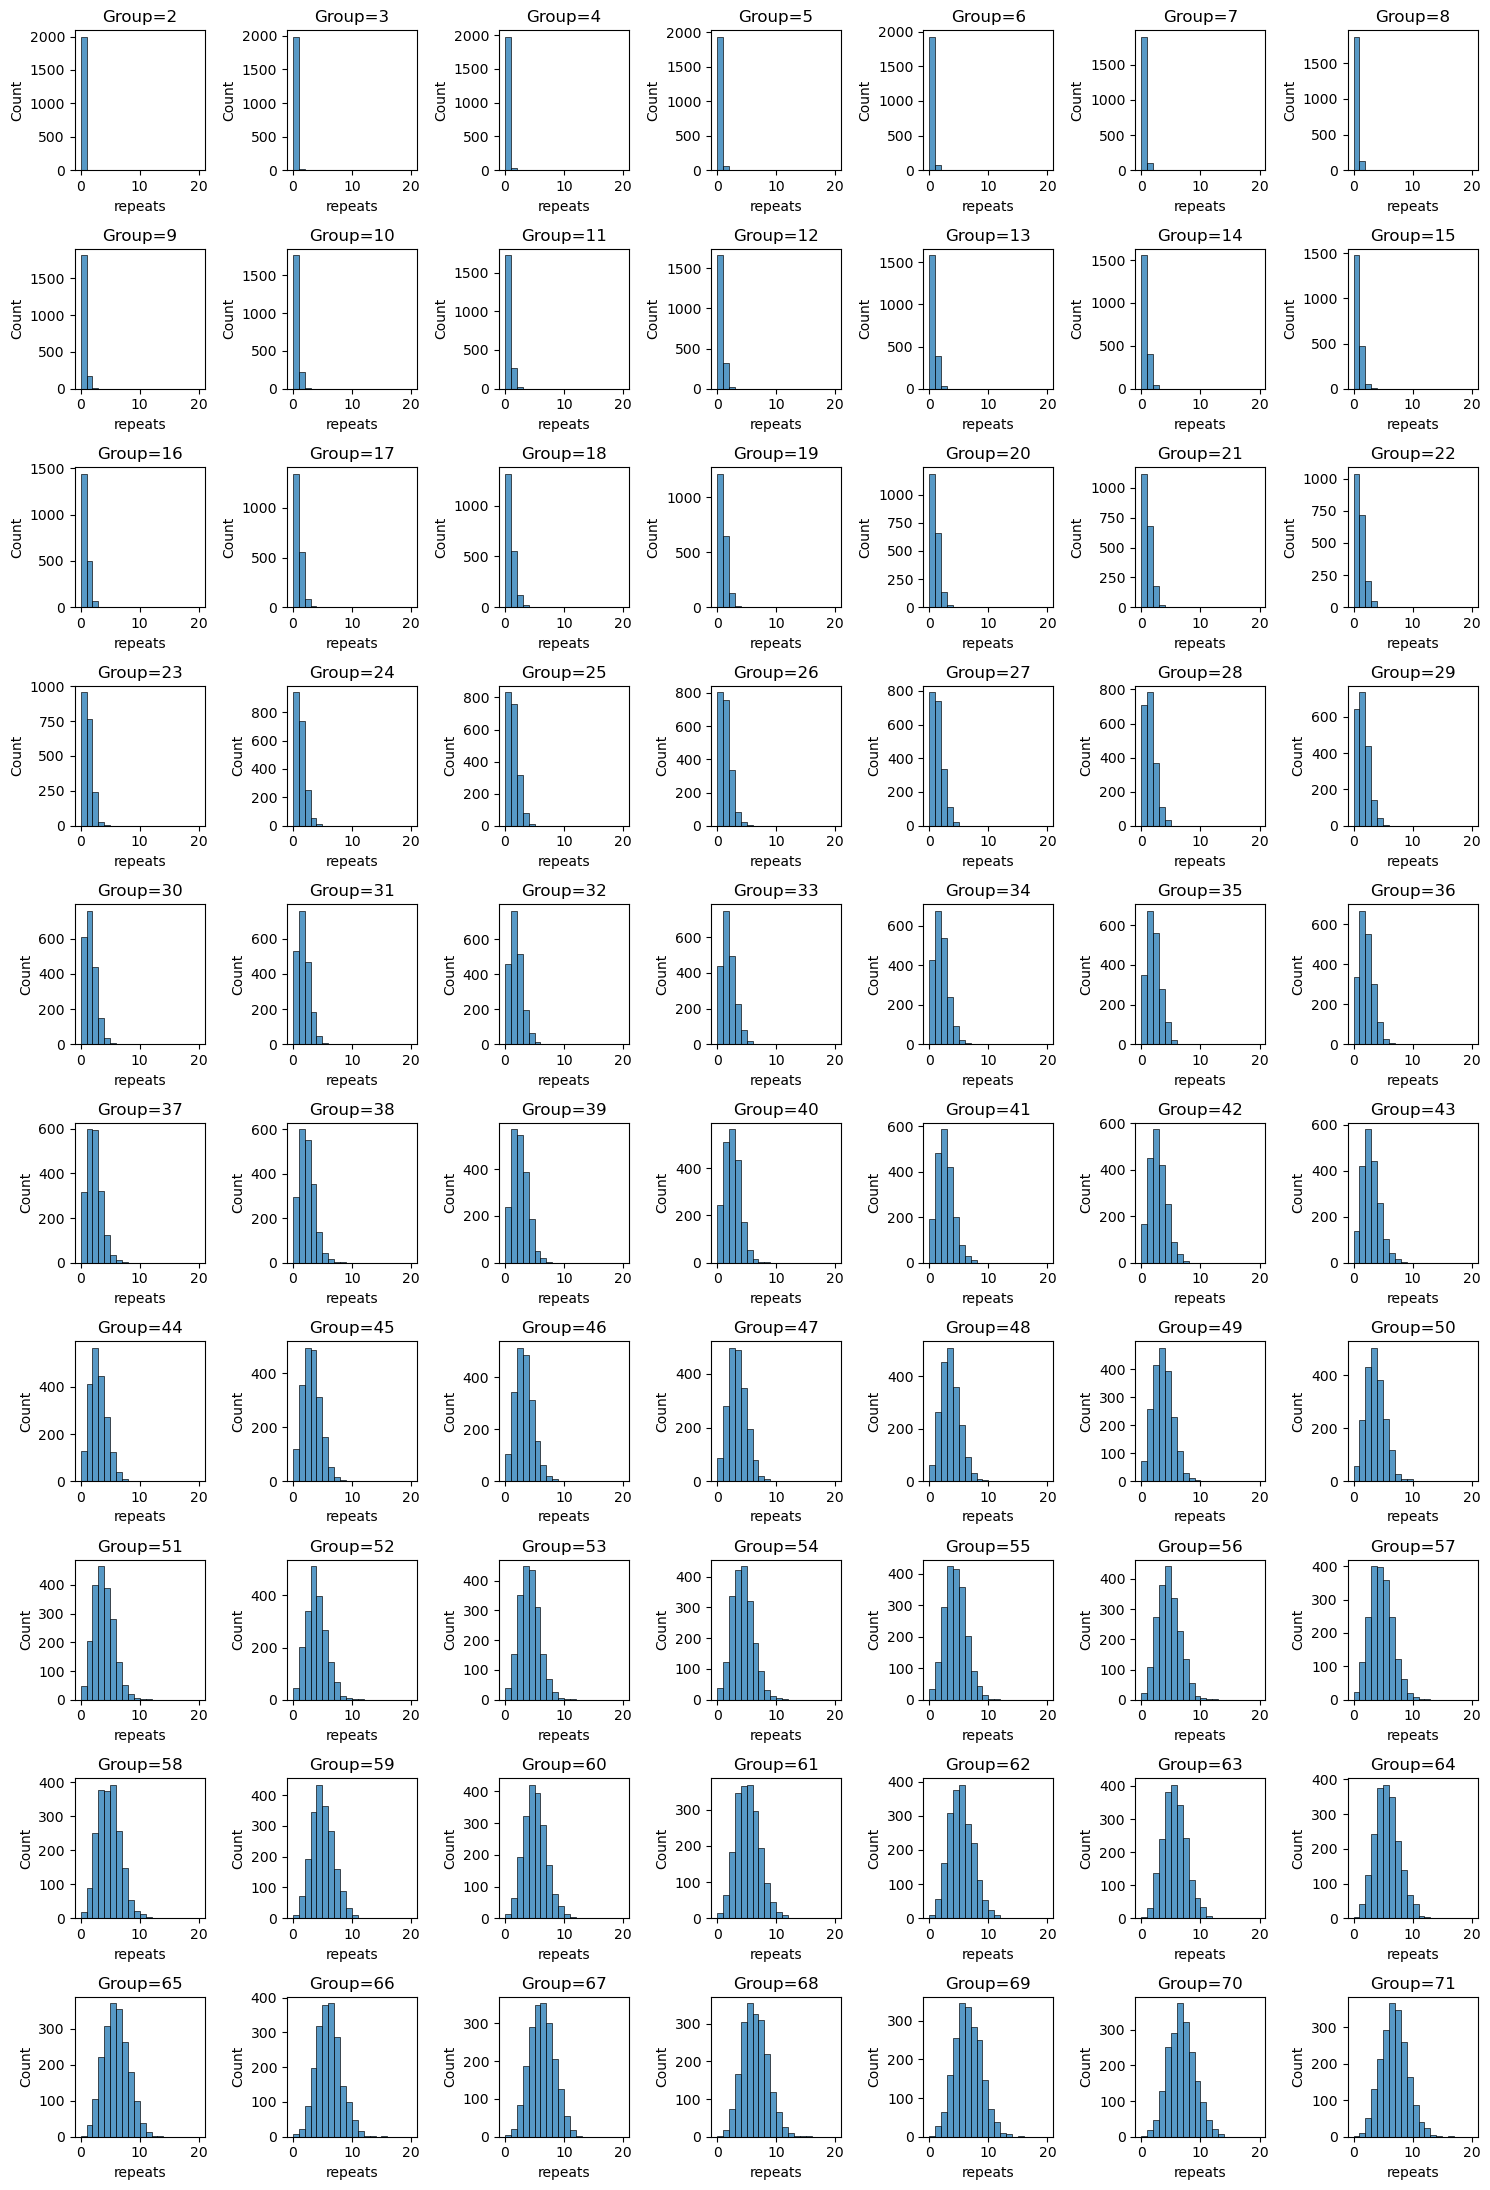

In [2]:
n = 72      # max group size
m = 2000    # samples used for estimating probabilities
data = {}   # samples data
pdata = []  # sample summary data
# Create a figure and a grid of subplots
fig, axes = plt.subplots(10, 7, figsize=(15, 22)) # 1 row, 3 columns
# print(axes.shape)
thresh = False
for i in range(2,n):
    data[i] = []
    for j in range(m):
        x = np.random.choice(range(365), i)
        # count repeated days - don't distinguish between e.g.
        # 2 2 2 2 => 4-1=3 and 3 3 4 4 4 => 5-2=3
        data[i].append(len(x) - len(set(x)))
    p = np.count_nonzero(data[i])/m
    pdata.append(p)
    if p > 0.5 and not thresh:
        print("Group size {:2} Avg={:2.2%}".format(i, p)) 
        thresh = True
    j, k = int((i-2)/7), (i-2)%7
    sns.histplot(data={"repeats": np.array(data[i])}, x="repeats", binrange=(0,20), bins=20, ax=axes[j,k])
    axes[j,k].set_title(f'Group={i}')
plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

We can also use the simpulation data to show the average propbabilities for the progression of groups sizes.

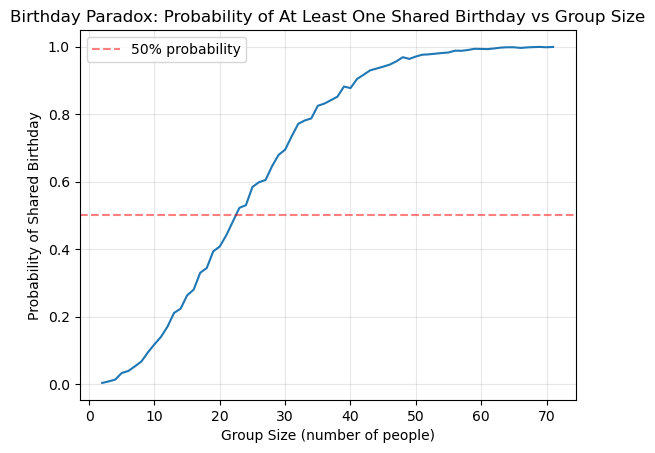

In [3]:
plt.plot(range(2,n), pdata)
plt.xlabel('Group Size (number of people)')
plt.ylabel('Probability of Shared Birthday')
plt.title('Birthday Paradox: Probability of At Least One Shared Birthday vs Group Size')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='50% probability')
plt.legend()
plt.show()

## Results Interpretation

The plot above shows the **cumulative distribution function (CDF)** of the birthday paradox. This curve represents the probability that at least one pair of people in a group shares the same birthday, as a function of group size.

### Key Observations:

- **Rapid Growth**: The probability increases rapidly in the range of 15-40 people, showing the counterintuitive nature of the paradox.
- **50% Threshold**: The red dashed line marks the 50% probability level. Notice that with just **23 people**, the probability exceeds 50%.
- **Near Certainty**: With around 50 people, the probability approaches nearly 90%, and with 70 people it's almost certain (>99%) that at least two people share a birthday.

### Why This is Surprising:

Most people intuitively expect you'd need around 183 people (half of 365) to have a 50% chance of a match. However, we're not looking for a *specific* birthday match, but *any* pair matching. With 23 people, there are **253 possible pairs** (23×22/2), which creates many opportunities for a collision.

## Do it again for 3 people having the same birthday

Group size 3 p = 0.00%
Group size 4 p = 0.00%
Group size 5 p = 0.00%
Group size 6 p = 0.00%
Group size 7 p = 0.00%
Group size 8 p = 0.05%
Group size 9 p = 0.05%
Group size 10 p = 0.00%
Group size 20 p = 0.95%
Group size 30 p = 3.05%
Group size 40 p = 7.75%
Group size 50 p = 11.80%
Group size 60 p = 21.35%
Group size 70 p = 31.90%
Group size 80 p = 42.55%
Group size 90 p = 52.40%
Group size 100 p = 64.30%
Group size 110 p = 75.00%
Group size 120 p = 83.25%
Group size 130 p = 89.90%
Group size 140 p = 93.85%


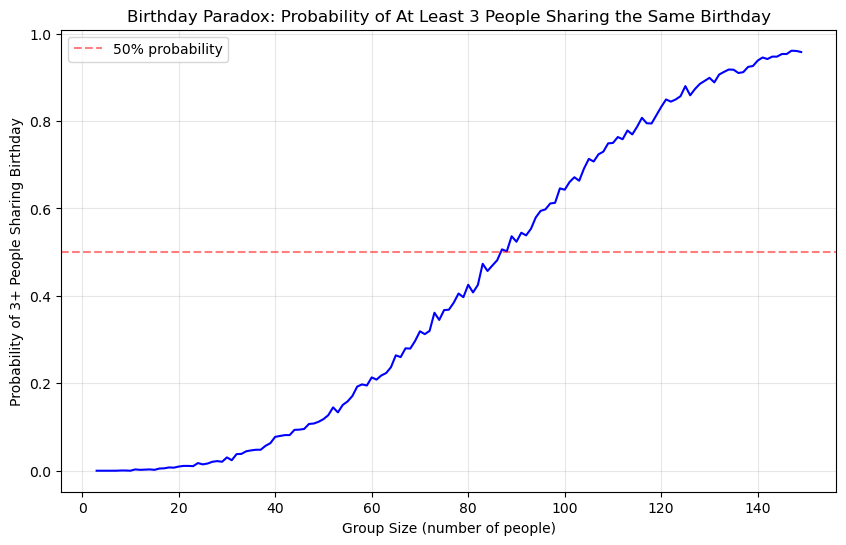


50% threshold reached at approximately 87 people


In [4]:
# Simulation for 3 people sharing the same birthday
n = 150  # Need larger group sizes for 3-way matches
m = 2000
pdata_triple = []
i
for i in range(3, n):
    matches = 0
    for j in range(m):
        birthdays = np.random.choice(range(365), i)
        # Count occurrences of each birthday
        _, counts = np.unique(birthdays, return_counts=True)
        # Check if any birthday appears 3 or more times
        if np.any(counts >= 3):
            matches += 1
    p = matches / m
    pdata_triple.append(p)
    if i % 10 == 0 or i < 10:
        print("Group size {} p = {:.2%}".format(i, p))

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(range(3, n), pdata_triple, color='blue')
plt.xlabel('Group Size (number of people)')
plt.ylabel('Probability of 3+ People Sharing Birthday')
plt.title('Birthday Paradox: Probability of At Least 3 People Sharing the Same Birthday')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='50% probability')
plt.legend()
plt.show()

# Find approximate group size for 50% probability
over = False
for idx, p in enumerate(pdata_triple):
    if p >= 0.5 and not over:
        over = True
        print(f"\n50% threshold reached at approximately {idx + 3} people")

## And for 4 people, given the groupsize and make the estimate of the mean, more precise

In [5]:
# Simulation for 4 people sharing the same birthday with group size 165 and a more precise estimate
group_size = 165
m = 23000
matches = 0

for j in range(m):
    birthdays = np.random.choice(range(365), group_size)
    # Count occurrences of each birthday
    _, counts = np.unique(birthdays, return_counts=True)
    # Check if any birthday appears 4 or more times
    if np.any(counts >= 4):
        matches += 1

p = matches / m
print(f"Group size: {group_size}")
print(f"Number of trials: {m}")
print(f"Probability of 4+ people sharing the same birthday: {p:.2%}")

Group size: 165
Number of trials: 23000
Probability of 4+ people sharing the same birthday: 35.60%
